In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)






In [27]:
df = pd.read_csv(r"C:\ds and AI\ALL DATASETS\nyc_housing_base.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34439 entries, 0 to 34438
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     34439 non-null  int64  
 1   block         34439 non-null  int64  
 2   lot           34439 non-null  int64  
 3   sale_price    34439 non-null  int64  
 4   zip_code      34423 non-null  float64
 5   borough_y     34439 non-null  str    
 6   yearbuilt     34439 non-null  float64
 7   lotarea       34439 non-null  float64
 8   bldgarea      34439 non-null  float64
 9   resarea       34251 non-null  float64
 10  comarea       34251 non-null  float64
 11  unitsres      34439 non-null  float64
 12  unitstotal    34439 non-null  float64
 13  numfloors     34396 non-null  float64
 14  latitude      34433 non-null  float64
 15  longitude     34433 non-null  float64
 16  landuse       34436 non-null  float64
 17  bldgclass     34439 non-null  str    
 18  building_age  34439 non-null  float64

In [28]:
print(df.shape)

df.info()

df.describe().T

(34439, 19)
<class 'pandas.DataFrame'>
RangeIndex: 34439 entries, 0 to 34438
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     34439 non-null  int64  
 1   block         34439 non-null  int64  
 2   lot           34439 non-null  int64  
 3   sale_price    34439 non-null  int64  
 4   zip_code      34423 non-null  float64
 5   borough_y     34439 non-null  str    
 6   yearbuilt     34439 non-null  float64
 7   lotarea       34439 non-null  float64
 8   bldgarea      34439 non-null  float64
 9   resarea       34251 non-null  float64
 10  comarea       34251 non-null  float64
 11  unitsres      34439 non-null  float64
 12  unitstotal    34439 non-null  float64
 13  numfloors     34396 non-null  float64
 14  latitude      34433 non-null  float64
 15  longitude     34433 non-null  float64
 16  landuse       34436 non-null  float64
 17  bldgclass     34439 non-null  str    
 18  building_age  34439 non-n

,count,mean,std,min,25%,50%,75%,max
borough_x,34439.0,3.073608e+00,1.287072e+00,1.000000,2.000000,3.000000,4.000000e+00,5.000000e+00
block,34439.0,4.562695e+03,3.611018e+03,1.000000,1432.000000,3854.000000,6.678000e+03,1.635000e+04
lot,34439.0,6.005717e+01,1.365166e+02,1.000000,14.000000,33.000000,5.900000e+01,3.635000e+03
sale_price,34439.0,1.171832e+06,1.241375e+06,11863.000000,512500.000000,825000.000000,1.300000e+06,9.995000e+06
zip_code,34423.0,1.086646e+04,5.577706e+02,10001.000000,10308.000000,11210.000000,1.136400e+04,1.169700e+04
yearbuilt,34439.0,1.941008e+03,2.898520e+01,1800.000000,1920.000000,1935.000000,1.960000e+03,2.025000e+03
lotarea,34439.0,5.244022e+04,5.032042e+05,161.000000,2090.000000,3090.000000,7.502000e+03,2.225160e+07
bldgarea,34439.0,6.271570e+04,2.712663e+05,0.000000,1614.500000,2494.000000,1.450000e+04,3.750565e+06
resarea,34251.0,5.593040e+04,2.116029e+05,0.000000,1356.000000,2120.000000,9.816000e+03,2.690565e+06
comarea,34251.0,6.846554e+03,6.971171e+04,0.000000,0.000000,0.000000,0.000000e+00,1.100000e+06


In [29]:
df.isnull().sum().sort_values(ascending=False)

resarea         188
comarea         188
numfloors        43
zip_code         16
latitude          6
longitude         6
landuse           3
lot               0
block             0
borough_x         0
sale_price        0
lotarea           0
bldgarea          0
borough_y         0
yearbuilt         0
unitsres          0
unitstotal        0
bldgclass         0
building_age      0
dtype: int64

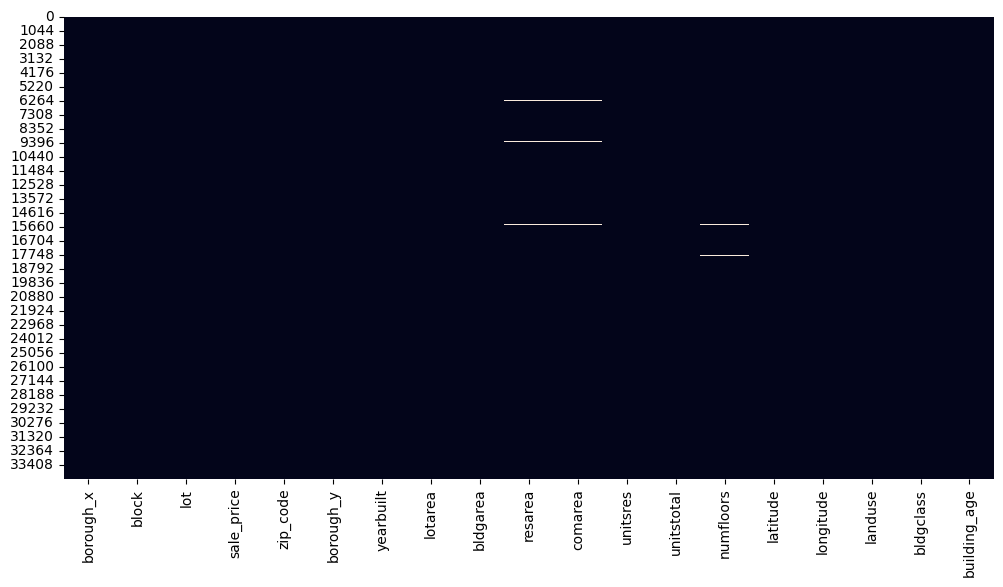

In [30]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False)
plt.show()

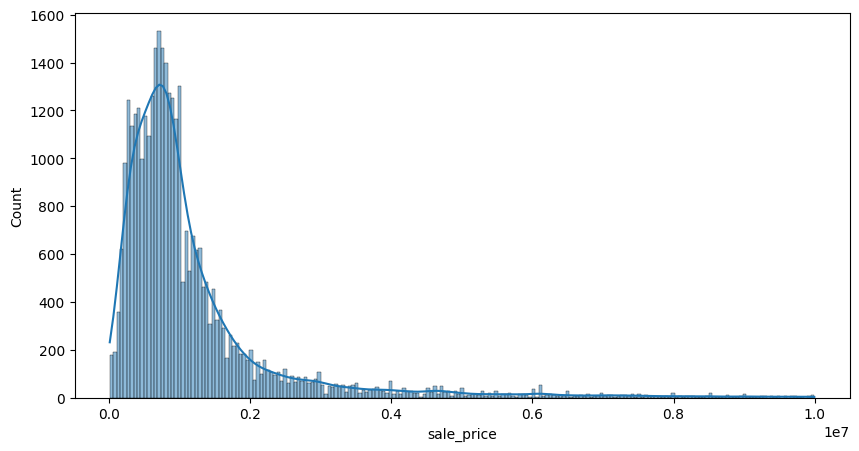

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(df["sale_price"],kde=True)
plt.show()

In [32]:
df["price_per_sqft"]=df["sale_price"]/(df["bldgarea"]+1)

df["area_ratio"]=df["resarea"]/(df["bldgarea"]+1)

df["total_units_per_floor"]=df["unitstotal"]/(df["numfloors"]+1)

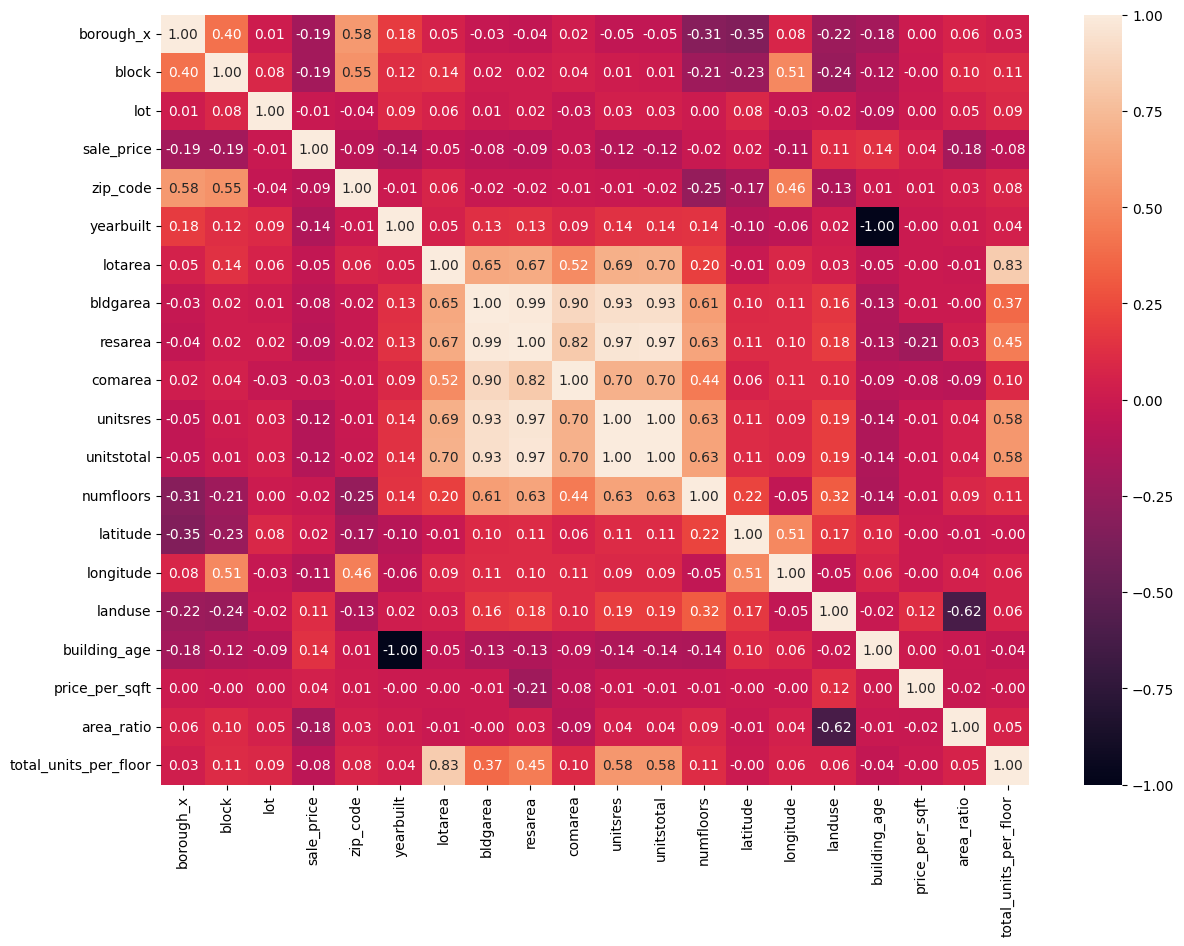

In [33]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True),
annot=True,
fmt=".2f")
plt.show()

In [34]:
X=df.drop("sale_price",axis=1)

y=df["sale_price"]

In [35]:
cat_cols=X.select_dtypes(include="object").columns

num_cols=X.select_dtypes(exclude="object").columns

C:\Users\VISWA\AppData\Local\Temp\ipykernel_17220\1477917269.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(include="object").columns


In [36]:
numeric_transformer=Pipeline([
("imputer",SimpleImputer(strategy="median")),
("scaler",StandardScaler())
])

categorical_transformer=Pipeline([
("imputer",SimpleImputer(strategy="most_frequent")),
("onehot",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor=ColumnTransformer([
("num",numeric_transformer,num_cols),
("cat",categorical_transformer,cat_cols)
])

In [37]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.2,
random_state=42
)

In [38]:
!pip install xgboost lightgbm catboost


In [39]:
from sklearn.ensemble import (
RandomForestRegressor,
AdaBoostRegressor,
GradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [40]:
models={

"RandomForest":
RandomForestRegressor(),

"AdaBoost":
AdaBoostRegressor(),

"GradientBoost":
GradientBoostingRegressor(),

"XGBoost":
XGBRegressor(),

"LightGBM":
LGBMRegressor(),

"CatBoost":
CatBoostRegressor(verbose=0)
}

In [41]:
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [42]:
models = {

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "GradientBoost": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        verbose=0,
        random_state=42
    )
}

In [43]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))
print(type(preprocessor))
print(type(models))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'dict'>


In [44]:
models={

"RandomForest":
RandomForestRegressor(
n_estimators=500,
max_depth=15,
random_state=42
),

"AdaBoost":
AdaBoostRegressor(
n_estimators=500,
learning_rate=0.05,
random_state=42
),

"GradientBoost":
GradientBoostingRegressor(
n_estimators=500,
learning_rate=0.05,
max_depth=6,
random_state=42
),

"XGBoost":
XGBRegressor(
n_estimators=1000,
learning_rate=0.03,
max_depth=8,
subsample=0.8,
colsample_bytree=0.8,
random_state=42
),

"LightGBM":
LGBMRegressor(
n_estimators=1000,
learning_rate=0.03,
random_state=42
),

"CatBoost":
CatBoostRegressor(
iterations=1000,
learning_rate=0.03,
depth=8,
verbose=0
)
}

In [46]:
results_df=pd.DataFrame(
results,
columns=[
"Model",
"MAE",
"RMSE",
"R2"
]
)

results_df.sort_values(
"R2",
ascending=False
)

,Model,MAE,RMSE,R2


In [49]:
!pip install KFold


ERROR: Could not find a version that satisfies the requirement KFold (from versions: none)
ERROR: No matching distribution found for KFold


In [47]:
best_model=models["CatBoost"]

pipe=Pipeline([
("prep",preprocessor),
("model",best_model)
])

cv=KFold(
n_splits=5,
shuffle=True,
random_state=42
)

scores=cross_val_score(
pipe,
X,
y,
cv=cv,
scoring="r2"
)

print(scores.mean())

NameError: name 'KFold' is not defined

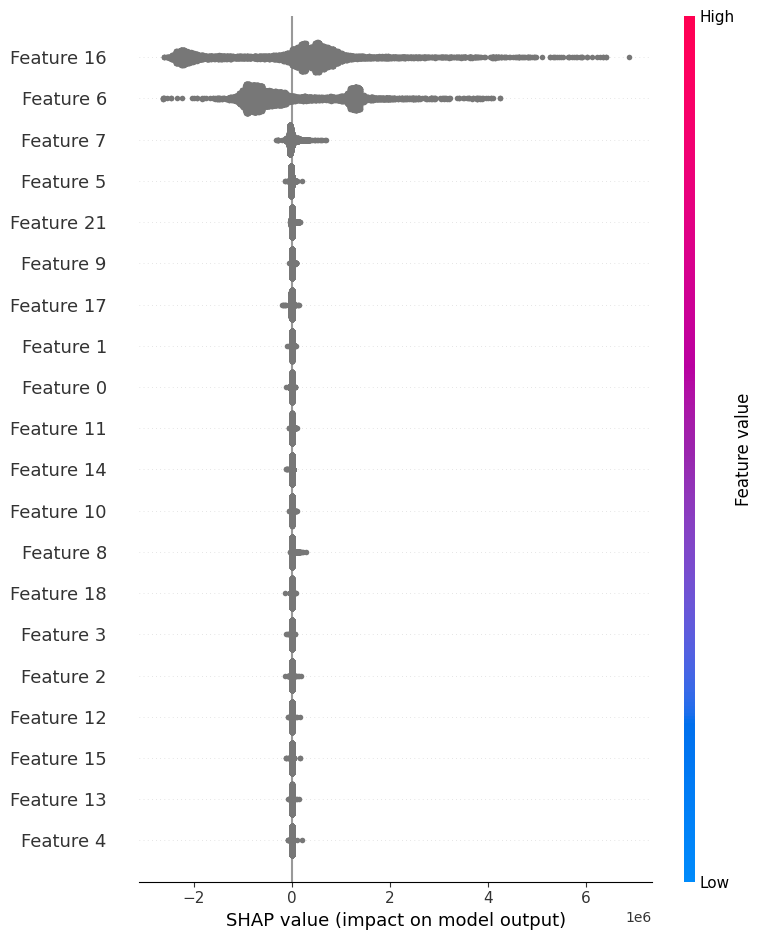

In [50]:
import shap

pipe.fit(X_train,y_train)

explainer=shap.Explainer(
pipe.named_steps["model"]
)

sample=pipe.named_steps[
"prep"
].transform(X_test)

shap_values=explainer(sample)

shap.summary_plot(
shap_values,
sample
)

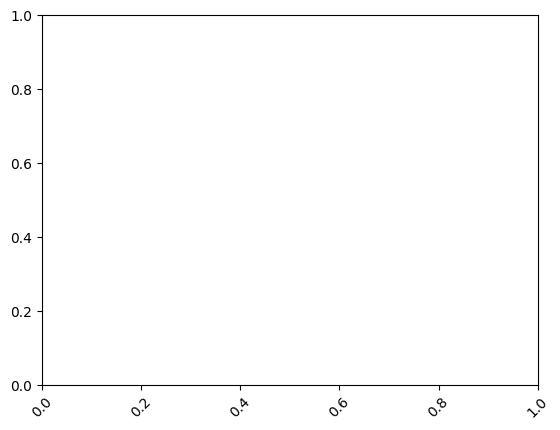

In [51]:
sns.barplot(
data=results_df,
x="Model",
y="R2"
)

plt.xticks(rotation=45)
plt.show()

In [52]:
import joblib

best_model=Pipeline([
("prep",preprocessor),
("model",CatBoostRegressor(verbose=0))
])

best_model.fit(X,y)

joblib.dump(
best_model,
"housing_model.pkl"
)

['housing_model.pkl']

In [54]:
print(df.columns.tolist())

['borough_x', 'block', 'lot', 'sale_price', 'zip_code', 'borough_y', 'yearbuilt', 'lotarea', 'bldgarea', 'resarea', 'comarea', 'unitsres', 'unitstotal', 'numfloors', 'latitude', 'longitude', 'landuse', 'bldgclass', 'building_age', 'price_per_sqft', 'area_ratio', 'total_units_per_floor']


In [53]:
sample=X.iloc[[0]]

prediction=best_model.predict(sample)

print(prediction)

[237001.67089036]


In [60]:
import os

print(os.getcwd())
print(os.listdir())

c:\ds and AI\ALL DATASETS\NYC Housing Prices boosting project
['app.py', 'catboost_info', 'housing_model.pkl', 'NYC Housing Prices.ipynb', 'nyc_housing_ai.pkl', 'nyc_housing_base.csv', 'requirements.txt']


In [61]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

try:
    from catboost import CatBoostRegressor
    _catboost_available = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    _catboost_available = False

# Load dataset
df = pd.read_csv(r"C:\ds and AI\ALL DATASETS\nyc_housing_base.csv")

# Replace with actual target
TARGET = "sale_price"

X = df.drop(TARGET, axis=1)
y = df[TARGET]

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        num_cols
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_cols
    )
])

if _catboost_available:
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        verbose=0
    )
else:
    model = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8
    )

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

pipe.fit(X, y)

joblib.dump(pipe, "nyc_housing_ai.pkl")

print("Model Saved Successfully")

C:\Users\VISWA\AppData\Local\Temp\ipykernel_17220\3332186945.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


Model Saved Successfully


In [63]:
import joblib

model = joblib.load("nyc_housing_ai.pkl")

print(
    model.named_steps["prep"].feature_names_in_
)

['borough_x' 'block' 'lot' 'zip_code' 'borough_y' 'yearbuilt' 'lotarea'
 'bldgarea' 'resarea' 'comarea' 'unitsres' 'unitstotal' 'numfloors'
 'latitude' 'longitude' 'landuse' 'bldgclass' 'building_age']


In [64]:
import pandas as pd

df = pd.read_csv("nyc_housing_base.csv")

print(df.columns.tolist())

['df = pd.read_csv(r"C:\\ds and AI\\ALL DATASETS\\nyc_housing_base.csv")']
